# Topic Extraction EDA

This notebook is a raw-data audit for `nyc311` topic extraction.

Setup for local use:
- run `uv sync --extra science --group notebooks`
- select the project `.venv` / `nyc311` kernel in Jupyter or VS Code

It shows how to:
- inspect the complaint-type distribution from a live 311 slice
- measure built-in topic-rule coverage
- inspect unmatched descriptors so topic logic does not silently lose signal
- add custom rules for a new complaint type
- render anomaly and report-style summaries directly inside the notebook

In [1]:
from pathlib import Path
import sys

from IPython.display import Markdown, display

import nyc311

repo_root = Path(nyc311.__file__).resolve().parents[2]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.utils import brooklyn_borough_filter, brooklyn_socrata_config

records = nyc311.fetch_service_requests(
    filters=brooklyn_borough_filter(
        start_date="2025-01-01",
        end_date="2025-03-31",
    ),
    socrata_config=brooklyn_socrata_config(page_size=1000, max_pages=5),
)

records_df = nyc311.records_to_dataframe(records)
records_df.head()

,service_request_id,created_date,complaint_type,descriptor,borough,community_district,resolution_description
0,63584096,2025-01-01,Noise - Residential,Loud Music/Party,BROOKLYN,01 BROOKLYN,The Police Department responded to the complai...
1,63575612,2025-01-01,Illegal Fireworks,N/A,BROOKLYN,14 BROOKLYN,The Police Department responded to the complai...
2,63572426,2025-01-01,Noise - Residential,Banging/Pounding,BROOKLYN,16 BROOKLYN,The Police Department responded to the complai...
3,63575947,2025-01-01,Noise - Residential,Loud Music/Party,BROOKLYN,18 BROOKLYN,The Police Department responded to the complai...
4,63585577,2025-01-01,Illegal Parking,Blocked Bike Lane,BROOKLYN,08 BROOKLYN,The Police Department responded to the complai...


,complaint_type,count
0,Illegal Parking,1117
1,HEAT/HOT WATER,582
2,Noise - Residential,509
3,Blocked Driveway,318
4,Street Condition,131
5,UNSANITARY CONDITION,128
6,Noise - Street/Sidewalk,125
7,Abandoned Vehicle,124
8,PLUMBING,113
9,Illegal Fireworks,105


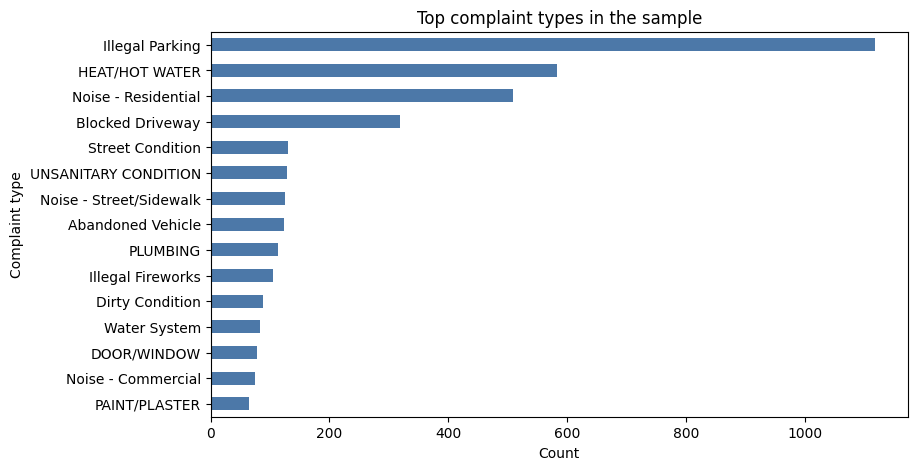

In [2]:
complaint_distribution = (
    records_df["complaint_type"]
    .value_counts()
    .rename_axis("complaint_type")
    .reset_index(name="count")
)

display(complaint_distribution.head(15))

plot_df = complaint_distribution.head(15).sort_values("count")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="complaint_type",
        y="count",
        figsize=(9, 5),
        color="#4C78A8",
        legend=False,
        title="Top complaint types in the sample",
    )
    ax.set_xlabel("Count")
    ax.set_ylabel("Complaint type")
    plt.show()
except ImportError:
    display(plot_df)

,complaint_type,total_records,matched_records,other_records,coverage_rate,top_unmatched_descriptors
4,Noise - Residential,509,480,29,0.943026,"[(Loud Talking, 29)]"
7,Street Condition,131,89,42,0.679389,"[(Wear & Tear, 16), (Rough, Pitted or Cracked ..."
6,Rodent,35,22,13,0.628571,"[(Signs of Rodents, 8), (Condition Attracting ..."
3,Illegal Parking,1117,444,673,0.397493,"[(Posted Parking Sign Violation, 295), (Blocke..."
8,UNSANITARY CONDITION,128,27,101,0.210938,"[(PESTS, 67), (MOLD, 34)]"
2,HEAT/HOT WATER,582,0,582,0.000000,"[(ENTIRE BUILDING, 370), (APARTMENT ONLY, 212)]"
1,Blocked Driveway,318,0,318,0.000000,"[(No Access, 216), (Partial Access, 102)]"
5,Noise - Street/Sidewalk,125,0,125,0.000000,"[(Loud Music/Party, 88), (Loud Talking, 37)]"
0,Abandoned Vehicle,124,0,124,0.000000,"[(With License Plate, 124)]"


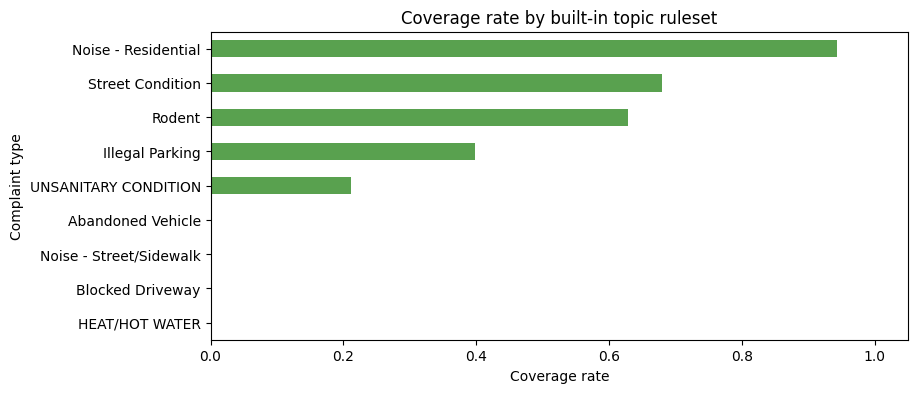

In [3]:
coverage_rows = []
for complaint_type in nyc311.supported_topic_queries():
    coverage = nyc311.analyze_topic_coverage(
        records,
        nyc311.TopicQuery(complaint_type=complaint_type, top_n=10),
    )
    coverage_rows.append(coverage)

coverage_df = nyc311.coverage_to_dataframe(coverage_rows).sort_values(
    ["coverage_rate", "total_records"],
    ascending=[False, False],
)
display(coverage_df)

plot_df = coverage_df.sort_values("coverage_rate")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="complaint_type",
        y="coverage_rate",
        figsize=(9, 4),
        color="#59A14F",
        legend=False,
        title="Coverage rate by built-in topic ruleset",
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Coverage rate")
    ax.set_ylabel("Complaint type")
    plt.show()
except ImportError:
    display(plot_df[["complaint_type", "coverage_rate", "other_records"]])

## Auditing Rule Coverage

The built-in topic constants are intended to be data-driven starting points, not hidden magic.

If a ruleset falls back to `other`, inspect the unmatched descriptors directly so you can decide whether to:
- keep the descriptor in `other`
- add a better built-in rule
- supply custom rules in your own workflow

In [4]:
illegal_parking_coverage = nyc311.analyze_topic_coverage(
    records,
    nyc311.TopicQuery("Illegal Parking", top_n=10),
)

unmatched_df = nyc311.records_to_dataframe(
    [
        nyc311.ServiceRequestRecord(
            service_request_id=f"unmatched-{index}",
            created_date=date(2025, 1, 1),
            complaint_type="Illegal Parking",
            descriptor=descriptor,
            borough=nyc311.BOROUGH_BROOKLYN,
            community_district="01 BROOKLYN",
        )
        for index, (descriptor, _count) in enumerate(
            illegal_parking_coverage.top_unmatched_descriptors,
            start=1,
        )
    ]
)[["descriptor"]]
unmatched_df["count"] = [
    count for _descriptor, count in illegal_parking_coverage.top_unmatched_descriptors
]
display(unmatched_df)

,descriptor,count
0,Posted Parking Sign Violation,295
1,Blocked Sidewalk,225
2,Commercial Overnight Parking,52
3,Parking Permit Improper Use,32
4,Blocked Bike Lane,30
5,License Plate Obscured,19
6,Paper License Plates,11
7,Unauthorized Bus Layover,5
8,Overnight Commercial Storage,3
9,Detached Trailer,1


In [5]:
custom_rules = (
    ("hydrant_issue", ("hydrant", "low water pressure")),
    ("leak", ("leak", "leaking")),
)

synthetic_records = [
    nyc311.ServiceRequestRecord(
        service_request_id="demo-1",
        created_date=date(2025, 1, 1),
        complaint_type="Water System",
        descriptor="Low water pressure near hydrant",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
    nyc311.ServiceRequestRecord(
        service_request_id="demo-2",
        created_date=date(2025, 1, 2),
        complaint_type="Water System",
        descriptor="Leaking hydrant on corner",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
    nyc311.ServiceRequestRecord(
        service_request_id="demo-3",
        created_date=date(2025, 1, 3),
        complaint_type="Water System",
        descriptor="Pressure issue in building basement",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
]

before_custom_rules = nyc311.analyze_topic_coverage(
    synthetic_records,
    nyc311.TopicQuery("Water System", top_n=10),
)
after_custom_rules = nyc311.analyze_topic_coverage(
    synthetic_records,
    nyc311.TopicQuery("Water System", top_n=10),
    custom_rules=custom_rules,
)

custom_coverage_df = nyc311.coverage_to_dataframe(
    [before_custom_rules, after_custom_rules]
)
custom_coverage_df.index = ["Fallback grouping", "Custom rules"]
display(custom_coverage_df)

,complaint_type,total_records,matched_records,other_records,coverage_rate,top_unmatched_descriptors
Fallback grouping,Water System,3,3,0,1.000000,[]
Custom rules,Water System,3,2,1,0.666667,"[(Pressure issue in building basement, 1)]"


,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,is_dominant_topic
0,community_district,01 BROOKLYN,Noise - Residential,party_music,22,37,0.594595,1,True
1,community_district,01 BROOKLYN,Noise - Residential,banging,13,37,0.351351,2,False
2,community_district,01 BROOKLYN,Noise - Residential,other,2,37,0.054054,3,False
3,community_district,02 BROOKLYN,Noise - Residential,banging,22,33,0.666667,1,True
4,community_district,02 BROOKLYN,Noise - Residential,party_music,11,33,0.333333,2,False
5,community_district,03 BROOKLYN,Noise - Residential,party_music,34,43,0.790698,1,True
6,community_district,03 BROOKLYN,Noise - Residential,banging,8,43,0.186047,2,False
7,community_district,03 BROOKLYN,Noise - Residential,other,1,43,0.023256,3,False
8,community_district,04 BROOKLYN,Noise - Residential,party_music,30,33,0.909091,1,True
9,community_district,04 BROOKLYN,Noise - Residential,other,2,33,0.060606,2,False


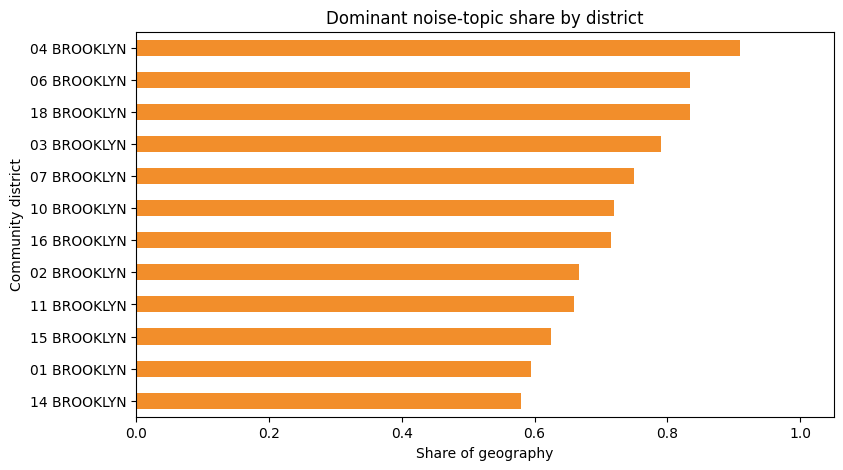

In [6]:
noise_assignments = nyc311.extract_topics(
    records,
    nyc311.TopicQuery("Noise - Residential", top_n=10),
)
noise_summaries = nyc311.aggregate_by_geography(
    noise_assignments,
    geography="community_district",
)
noise_summaries_df = nyc311.summaries_to_dataframe(noise_summaries)
display(noise_summaries_df.head(10))

dominant_noise_df = noise_summaries_df[
    noise_summaries_df["is_dominant_topic"]
].sort_values(
    "share_of_geography",
    ascending=False,
)
try:
    import matplotlib.pyplot as plt

    ax = (
        dominant_noise_df.head(12)
        .sort_values("share_of_geography")
        .plot.barh(
            x="geography_value",
            y="share_of_geography",
            figsize=(9, 5),
            color="#F28E2B",
            legend=False,
            title="Dominant noise-topic share by district",
        )
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Share of geography")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(
        dominant_noise_df[["geography_value", "topic", "share_of_geography"]].head(12)
    )

## Inline Audit Summary
- Complaint types audited: 9
- Best built-in coverage rate: 94.3%
- Noise anomaly flags above threshold: 4
- Resolution rows available: 119

,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,z_score,is_anomaly,window_days,anomaly_threshold
0,community_district,03 BROOKLYN,Noise - Residential,party_music,34,43,0.790698,1,2.713350,True,30,1.5
1,community_district,11 BROOKLYN,Noise - Residential,party_music,31,47,0.659574,1,2.371618,True,30,1.5
2,community_district,04 BROOKLYN,Noise - Residential,party_music,30,33,0.909091,1,2.257708,True,30,1.5
3,community_district,05 BROOKLYN,Noise - Residential,party_music,30,56,0.535714,1,2.257708,True,30,1.5
4,community_district,01 BROOKLYN,Noise - Residential,party_music,22,37,0.594595,1,1.346423,False,30,1.5
5,community_district,02 BROOKLYN,Noise - Residential,banging,22,33,0.666667,1,1.346423,False,30,1.5
6,community_district,05 BROOKLYN,Noise - Residential,banging,22,56,0.392857,2,1.346423,False,30,1.5
7,community_district,14 BROOKLYN,Noise - Residential,party_music,22,38,0.578947,1,1.346423,False,30,1.5
8,community_district,03 BROOKLYN,Noise - Residential,other,1,43,0.023256,3,-1.045699,False,30,1.5
9,community_district,04 BROOKLYN,Noise - Residential,banging,1,33,0.030303,3,-1.045699,False,30,1.5


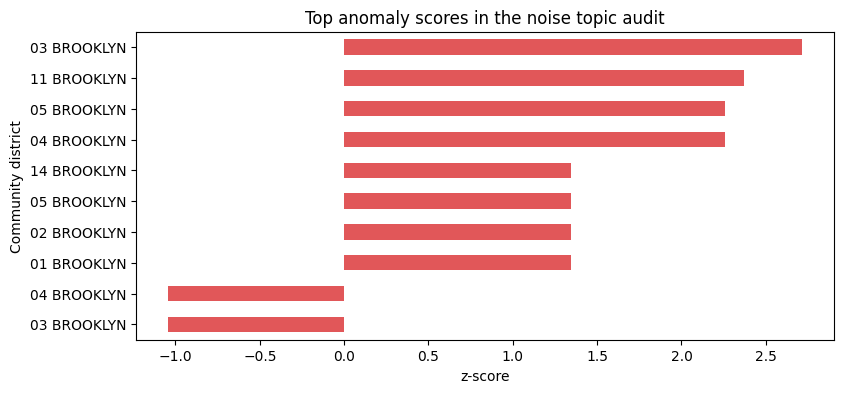

In [7]:
anomalies = nyc311.detect_anomalies(
    noise_summaries,
    nyc311.AnalysisWindow(days=30),
    z_threshold=1.5,
)
anomalies_df = nyc311.anomalies_to_dataframe(anomalies)

resolution_gaps = nyc311.analyze_resolution_gaps(
    records,
    [record for record in records if record.resolution_description is not None],
)
resolution_df = nyc311.gaps_to_dataframe(resolution_gaps)

display(
    Markdown(
        "\n".join(
            [
                "## Inline Audit Summary",
                f"- Complaint types audited: {coverage_df.shape[0]}",
                f"- Best built-in coverage rate: {coverage_df['coverage_rate'].max():.1%}",
                f"- Noise anomaly flags above threshold: {int(anomalies_df['is_anomaly'].sum())}",
                f"- Resolution rows available: {resolution_df.shape[0]}",
            ]
        )
    )
)

display(anomalies_df.head(10))

plot_df = anomalies_df.head(10).sort_values("z_score")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="geography_value",
        y="z_score",
        figsize=(9, 4),
        color="#E15759",
        legend=False,
        title="Top anomaly scores in the noise topic audit",
    )
    ax.set_xlabel("z-score")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(plot_df[["geography_value", "topic", "z_score", "is_anomaly"]])